In [24]:
import tensorflow as tf


In [4]:
# Define input shape
n = 16
in_shape = (n, 1)

In [26]:
class SequentialNN(tf.keras.models.Sequential):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def predict_trustee(self, x):
        pred_probs = super().predict(x)
        rounded_probs = tf.math.round(pred_probs)
        predictions = tf.cast(rounded_probs, tf.int32).numpy()
        return predictions.flatten()

In [6]:
model = SequentialNN()

In [7]:
import math
f = n
k = 4

model.add(tf.keras.layers.Conv1D(filters=f, kernel_size=k, activation='relu', input_shape=in_shape))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(tf.keras.layers.MaxPooling1D(pool_size=2, strides=1, padding='valid'))

In [9]:
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [10]:
model.summary()

Model: "sequential_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 13, 16)         │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

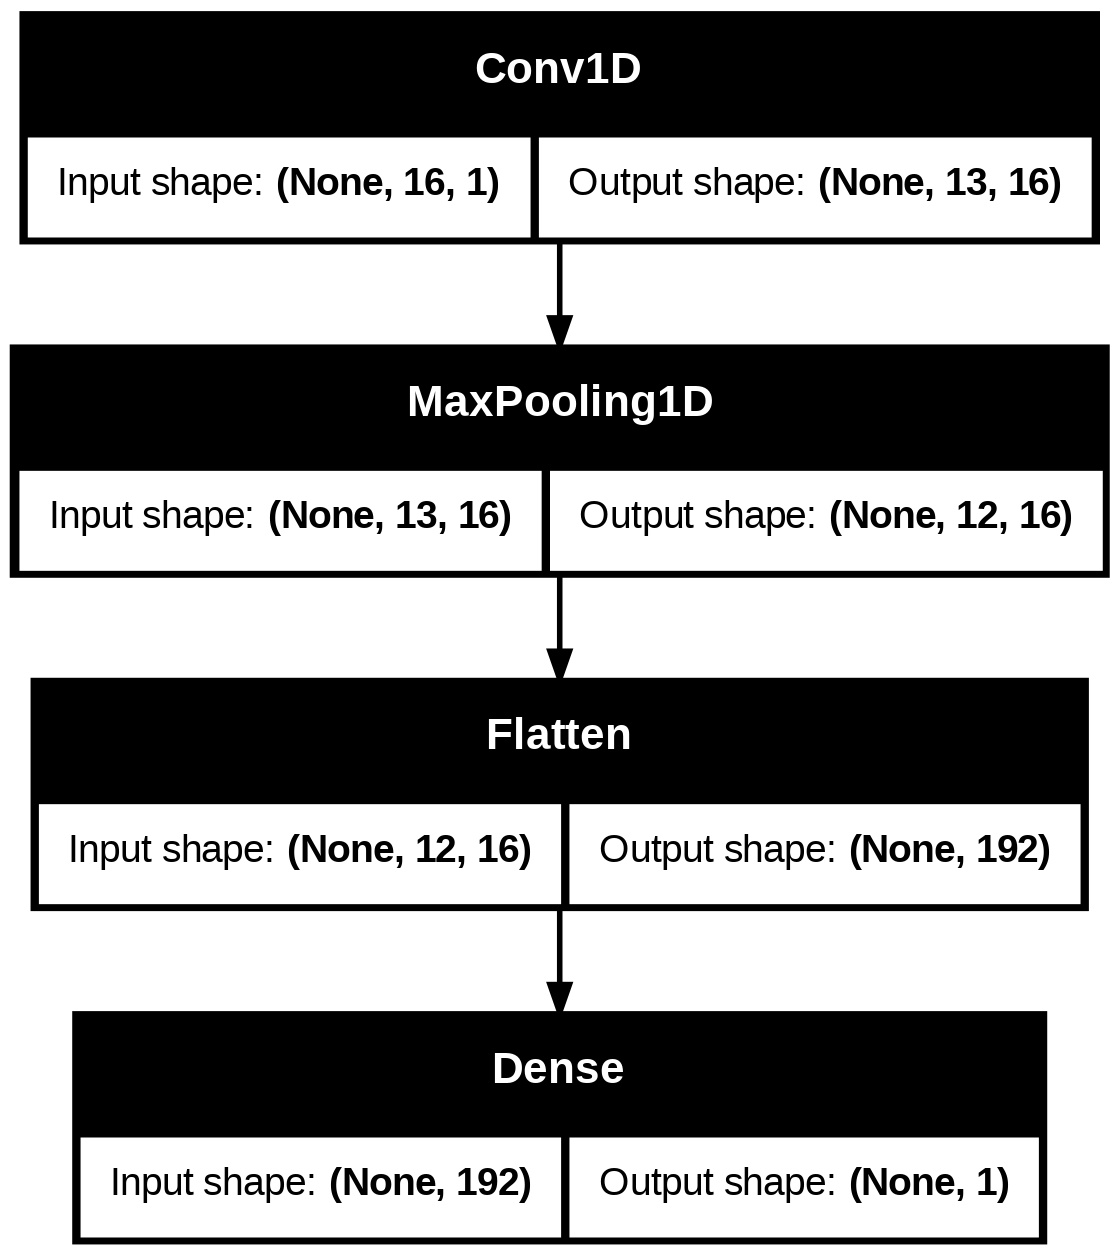

In [11]:
tf.keras.utils.plot_model(model, to_file="cnn_model.png", show_shapes=True)

In [13]:
model.save('untrained-cnn-model.keras')

In [14]:
import pandas as pd

normal_doh_traffic_dataset = '/content/normal_doh_traffic_cloudflare_server.csv'
malicious_doh_traffic_dataset = '/content/dnscat2_data_4.csv'

# Load the datasets into Pandas dataframes
normal_traffic_df    = pd.read_csv(normal_doh_traffic_dataset)
malicious_traffic_df = pd.read_csv(malicious_doh_traffic_dataset)

In [16]:
# Sample malicious traffic
malicious_samples = malicious_traffic_df.sample(normal_traffic_df.shape[0])

# Concatenate dataframes
main_df = pd.concat([normal_traffic_df, malicious_samples])

# Shuffle the  samples in the whole dataset.
main_df = main_df.sample(main_df.shape[0], random_state=1)

# change malicious label from 4 to 0
main_df['is_doh'] = main_df['is_doh'].replace(4, 0)

# Save to CSV file
main_df.to_csv('[combines.csv')

In [17]:
from sklearn.model_selection import train_test_split

X = main_df.drop('is_doh', axis=1)
y = main_df['is_doh']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Saving splitted data
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [18]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, \
                    validation_data=(X_test, y_test))

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9404 - loss: 0.5514 - val_accuracy: 0.9468 - val_loss: 0.4067
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9641 - loss: 0.3022 - val_accuracy: 0.9872 - val_loss: 0.2268
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9957 - loss: 0.1692 - val_accuracy: 0.9979 - val_loss: 0.1298
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9981 - loss: 0.0960 - val_accuracy: 0.9979 - val_loss: 0.0788
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9981 - loss: 0.0587 - val_accuracy: 0.9979 - val_loss: 0.0532


In [20]:
import json

# Convert the history.history dict to a JSON object
json_history = json.dumps(history.history)

# Write the JSON object to a file
with open('training_history.json', 'w') as file:
	file.write(json_history)

In [21]:
model.save('trained_model.keras')

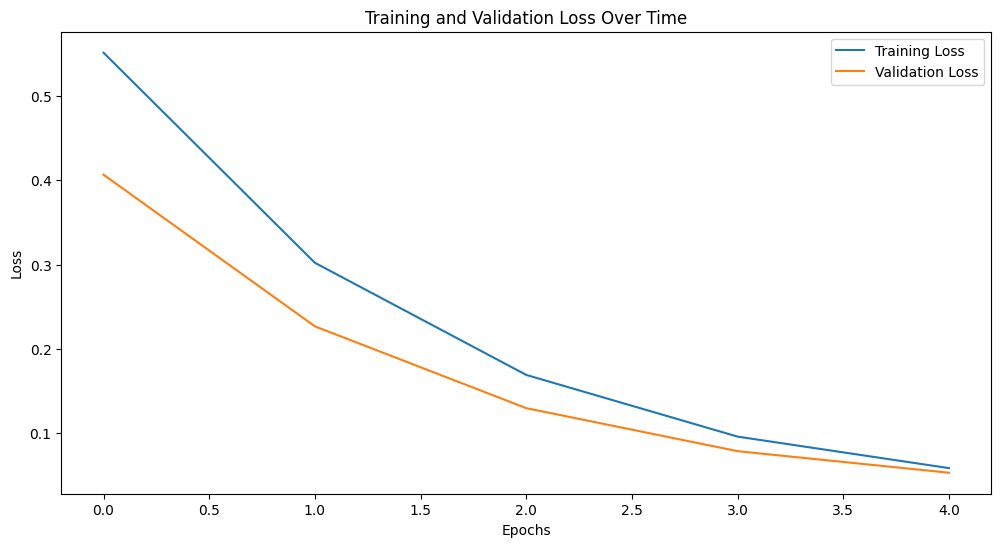

In [22]:
import matplotlib.pyplot as plt

# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_plot.png')
plt.show()

# Changes


In [28]:
from tensorflow.keras.models import load_model


model = load_model('untrained-cnn-model.keras', custom_objects={'SequentialNN': SequentialNN})

In [29]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
history = model.fit(X_train, y_train, epochs=20, batch_size=16, \
                    validation_data=(X_test, y_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8936 - loss: 0.4529 - val_accuracy: 0.9798 - val_loss: 0.2573
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9947 - loss: 0.1550 - val_accuracy: 0.9979 - val_loss: 0.0954
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9981 - loss: 0.0600 - val_accuracy: 0.9979 - val_loss: 0.0464
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0307 - val_accuracy: 0.9979 - val_loss: 0.0303
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0195 - val_accuracy: 0.9979 - val_loss: 0.0232
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0141 - val_accuracy: 0.9979 - val_loss: 0.0194
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0113 - val_accuracy: 0.9979 - val_loss: 0.0180
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0096 - val_accuracy: 0

In [31]:
import json

json_history = json.dumps(history.history)

with open('training_history_updated.json', 'w') as file:
	file.write(json_history)

model.save('trained_model_updated.keras')

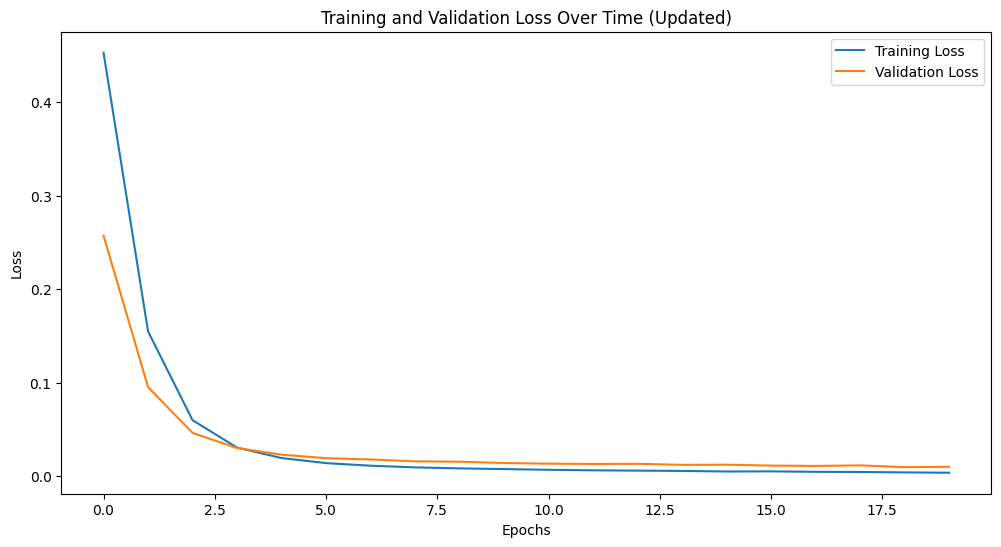

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Time (Updated)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_plot_updated.png')
plt.show()

# CNN MODEL NEW ARCHITECTURE

In [38]:
model2 = SequentialNN()

# First Conv1D layer
model2.add(tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(16,1)))
model2.add(tf.keras.layers.MaxPooling1D(pool_size=2, strides=2, padding='valid'))

# Second Conv1D layer
model2.add(tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu'))
model2.add(tf.keras.layers.MaxPooling1D(pool_size=2, strides=2, padding='valid'))

# Flatten and output
model2.add(tf.keras.layers.Flatten())
model2.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model2.summary()

Model: "sequential_nn_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 14, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 5, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(X_train, y_train, epochs=20, batch_size=16, \
                      validation_data=(X_test, y_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9492 - loss: 0.2816 - val_accuracy: 0.9979 - val_loss: 0.0607
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9984 - loss: 0.0260 - val_accuracy: 0.9979 - val_loss: 0.0235
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9989 - loss: 0.0121 - val_accuracy: 0.9979 - val_loss: 0.0188
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9989 - loss: 0.0097 - val_accuracy: 0.9979 - val_loss: 0.0178
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9989 - loss: 0.0084 - val_accuracy: 0.9979 - val_loss: 0.0184
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9989 - loss: 0.0073 - val_accuracy: 0.9979 - val_loss: 0.0182
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0071 - val_accuracy: 0.9979 - val_loss: 0.0176
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9989 - loss: 0.0066 - val_accuracy: 0.

In [41]:
import json

json_history2 = json.dumps(history2.history)

with open('training_history_model2.json', 'w') as file:
    file.write(json_history2)

model2.save('trained_model2.keras')

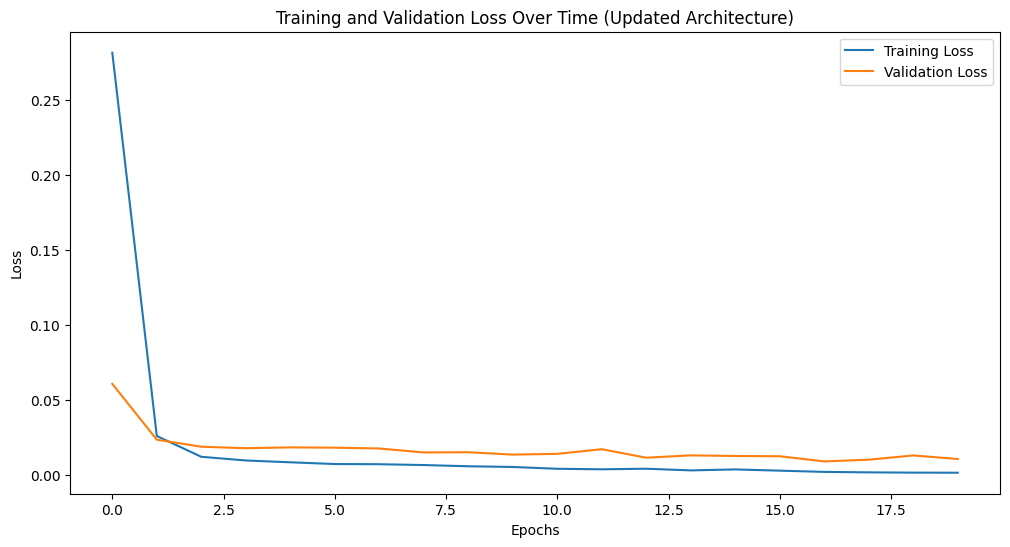

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Time (Updated Architecture)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_plot_model2.png')
plt.show()

In [43]:
import shutil

shutil.make_archive('my_project', 'zip', '/content')

'/content/my_project.zip'

In [44]:
from google.colab import files
files.download('my_project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>